In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import ast
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded!")

All libraries loaded!


In [3]:
movies = pd.read_csv('tmdb_5000_movies.csv')
credits = pd.read_csv('tmdb_5000_credits.csv')

print("Movies shape:", movies.shape)
print("Credits shape:", credits.shape)
movies.head()

Movies shape: (4803, 20)
Credits shape: (4803, 4)


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [4]:
# Merge movies and credits
movies = movies.merge(credits, on='title')

# Keep only useful columns
movies = movies[['movie_id', 'title', 'overview', 'genres', 'keywords', 'cast', 'crew']]

print("Shape after merge:", movies.shape)
movies.head()

Shape after merge: (4809, 7)


,movie_id,title,overview,genres,keywords,cast,crew
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...","[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...","[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...","[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,A cryptic message from Bond’s past sends him o...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...","[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,Following the death of District Attorney Harve...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...","[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...","[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"John Carter is a war-weary, former military ca...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 818, ""name"": ""based on novel""}, {""id"":...","[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [5]:
# Convert string to list for genres, keywords, cast, crew
def convert(text):
    return [i['name'] for i in ast.literal_eval(text)]

def convert_cast(text):
    return [i['name'] for i in ast.literal_eval(text)][:5]  # top 5 cast only

def fetch_director(text):
    for i in ast.literal_eval(text):
        if i['job'] == 'Director':
            return [i['name']]
    return []

movies.dropna(inplace=True)

movies['genres'] = movies['genres'].apply(convert)
movies['keywords'] = movies['keywords'].apply(convert)
movies['cast'] = movies['cast'].apply(convert_cast)
movies['crew'] = movies['crew'].apply(fetch_director)

print("Done!")
movies.head()

Done!


,movie_id,title,overview,genres,keywords,cast,crew
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...","[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colon...","[Sam Worthington, Zoe Saldana, Sigourney Weave...",[James Cameron]
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[Adventure, Fantasy, Action]","[ocean, drug abuse, exotic island, east india ...","[Johnny Depp, Orlando Bloom, Keira Knightley, ...",[Gore Verbinski]
2,206647,Spectre,A cryptic message from Bond’s past sends him o...,"[Action, Adventure, Crime]","[spy, based on novel, secret agent, sequel, mi...","[Daniel Craig, Christoph Waltz, Léa Seydoux, R...",[Sam Mendes]
3,49026,The Dark Knight Rises,Following the death of District Attorney Harve...,"[Action, Crime, Drama, Thriller]","[dc comics, crime fighter, terrorist, secret i...","[Christian Bale, Michael Caine, Gary Oldman, A...",[Christopher Nolan]
4,49529,John Carter,"John Carter is a war-weary, former military ca...","[Action, Adventure, Science Fiction]","[based on novel, mars, medallion, space travel...","[Taylor Kitsch, Lynn Collins, Samantha Morton,...",[Andrew Stanton]


In [6]:
# Remove spaces from names so "Sam Worthington" becomes "SamWorthington"
def collapse(lst):
    return [i.replace(" ", "") for i in lst]

movies['genres'] = movies['genres'].apply(collapse)
movies['keywords'] = movies['keywords'].apply(collapse)
movies['cast'] = movies['cast'].apply(collapse)
movies['crew'] = movies['crew'].apply(collapse)

# Convert overview from string to list
movies['overview'] = movies['overview'].apply(lambda x: x.split())

# Combine everything into one tags column
movies['tags'] = movies['overview'] + movies['genres'] + movies['keywords'] + movies['cast'] + movies['crew']

# Create final dataframe
new_df = movies[['movie_id', 'title', 'tags']].copy()
new_df['tags'] = new_df['tags'].apply(lambda x: " ".join(x).lower())

print("Sample tags for Avatar:")
print(new_df['tags'][0])

Sample tags for Avatar:
in the 22nd century, a paraplegic marine is dispatched to the moon pandora on a unique mission, but becomes torn between following orders and protecting an alien civilization. action adventure fantasy sciencefiction cultureclash future spacewar spacecolony society spacetravel futuristic romance space alien tribe alienplanet cgi marine soldier battle loveaffair antiwar powerrelations mindandsoul 3d samworthington zoesaldana sigourneyweaver stephenlang michellerodriguez jamescameron


In [7]:
# Convert tags to vectors
cv = CountVectorizer(max_features=5000, stop_words='english')
vectors = cv.fit_transform(new_df['tags']).toarray()

# Calculate similarity between all movies
similarity = cosine_similarity(vectors)

print("Similarity matrix shape:", similarity.shape)
print("Done! Recommendation engine ready!")


Similarity matrix shape: (4806, 4806)
Done! Recommendation engine ready!


In [8]:
def recommend(movie):
    # Find the movie index
    movie_index = new_df[new_df['title'] == movie].index[0]
    
    # Get similarity scores for this movie
    distances = similarity[movie_index]
    
    # Sort and get top 5 similar movies
    movies_list = sorted(list(enumerate(distances)), reverse=True, key=lambda x: x[1])[1:6]
    
    print(f"\n🎬 Because you liked '{movie}', you might also like:\n")
    for i, (idx, score) in enumerate(movies_list):
        print(f"{i+1}. {new_df.iloc[idx]['title']} (similarity: {score:.2f})")

# Try it!
recommend("Avatar")


🎬 Because you liked 'Avatar', you might also like:

1. Independence Day (similarity: 0.25)
2. Titan A.E. (similarity: 0.25)
3. Aliens vs Predator: Requiem (similarity: 0.24)
4. Small Soldiers (similarity: 0.24)
5. Battle: Los Angeles (similarity: 0.24)


In [9]:
# Visualisation 1: Top 10 most popular movies
plt.figure(figsize=(12,5))
top_movies = movies.nlargest(10, 'popularity') if 'popularity' in movies.columns else movies.head(10)
sns.barplot(x='popularity', y='title', data=movies.nlargest(10, 'popularity'), palette='viridis')
plt.title('Top 10 Most Popular Movies')
plt.xlabel('Popularity Score')
plt.ylabel('Movie')
plt.tight_layout()
plt.savefig('top_movies.png')
plt.show()

# Visualisation 2: Genre distribution
from collections import Counter
all_genres = []
for genre_list in movies['genres']:
    all_genres.extend(genre_list)

genre_counts = Counter(all_genres)
top_genres = dict(sorted(genre_counts.items(), key=lambda x: x[1], reverse=True)[:10])

plt.figure(figsize=(12,5))
sns.barplot(x=list(top_genres.values()), y=list(top_genres.keys()), palette='coolwarm')
plt.title('Top 10 Most Common Genres')
plt.xlabel('Number of Movies')
plt.tight_layout()
plt.savefig('genre_distribution.png')
plt.show()

print("Graphs saved!")

KeyError: 'popularity'

<Figure size 1200x500 with 0 Axes>

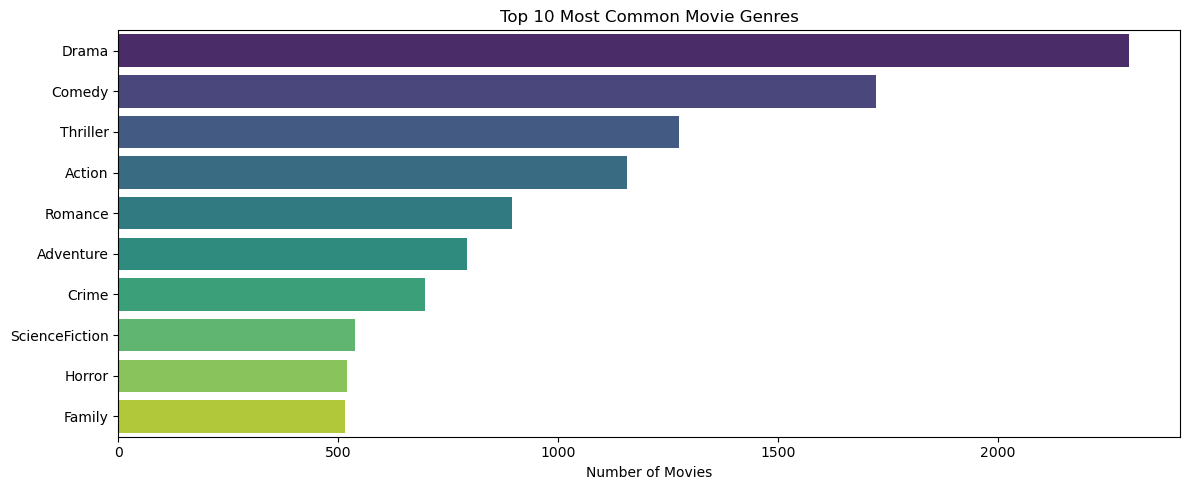

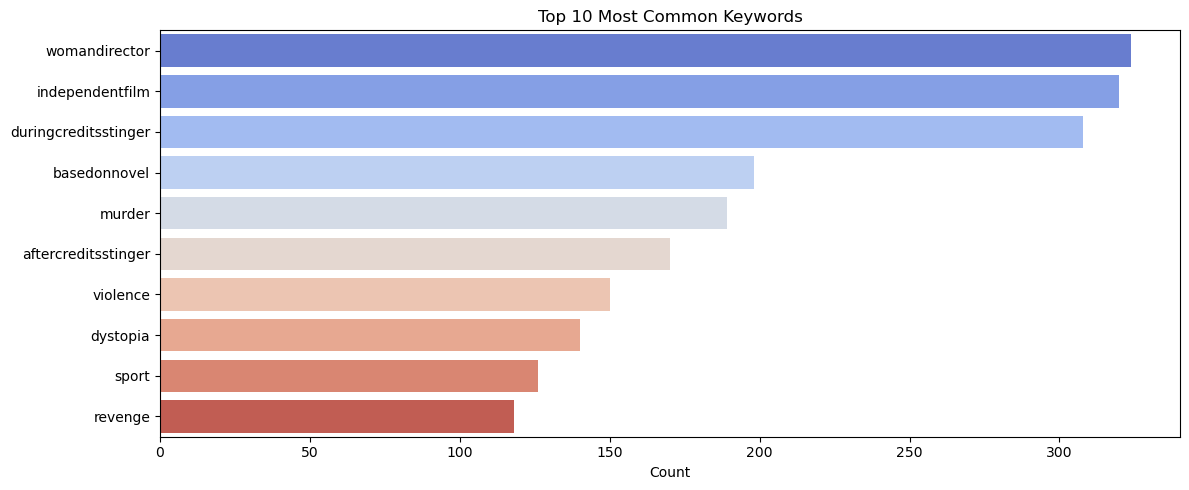

Graphs saved!


In [10]:
# Visualisation 1: Top 10 genres
from collections import Counter
all_genres = []
for genre_list in movies['genres']:
    all_genres.extend(genre_list)

genre_counts = Counter(all_genres)
top_genres = dict(sorted(genre_counts.items(), key=lambda x: x[1], reverse=True)[:10])

plt.figure(figsize=(12,5))
sns.barplot(x=list(top_genres.values()), y=list(top_genres.keys()), palette='viridis')
plt.title('Top 10 Most Common Movie Genres')
plt.xlabel('Number of Movies')
plt.tight_layout()
plt.savefig('genre_distribution.png')
plt.show()

# Visualisation 2: Top 10 keywords
all_keywords = []
for kw_list in movies['keywords']:
    all_keywords.extend(kw_list)

kw_counts = Counter(all_keywords)
top_kw = dict(sorted(kw_counts.items(), key=lambda x: x[1], reverse=True)[:10])

plt.figure(figsize=(12,5))
sns.barplot(x=list(top_kw.values()), y=list(top_kw.keys()), palette='coolwarm')
plt.title('Top 10 Most Common Keywords')
plt.xlabel('Count')
plt.tight_layout()
plt.savefig('keywords.png')
plt.show()

print("Graphs saved!")

In [11]:
# Try different movies!
recommend("The Dark Knight Rises")
print("\n" + "="*50 + "\n")
recommend("The Avengers")
print("\n" + "="*50 + "\n")
recommend("Inception")


🎬 Because you liked 'The Dark Knight Rises', you might also like:

1. The Dark Knight (similarity: 0.43)
2. Batman Begins (similarity: 0.37)
3. Batman (similarity: 0.34)
4. Batman Returns (similarity: 0.33)
5. Batman (similarity: 0.32)



🎬 Because you liked 'The Avengers', you might also like:

1. Avengers: Age of Ultron (similarity: 0.42)
2. Captain America: Civil War (similarity: 0.34)
3. Iron Man 3 (similarity: 0.29)
4. Captain America: The First Avenger (similarity: 0.29)
5. Iron Man 2 (similarity: 0.29)



🎬 Because you liked 'Inception', you might also like:

1. Duplex (similarity: 0.22)
2. The Helix... Loaded (similarity: 0.20)
3. Star Trek II: The Wrath of Khan (similarity: 0.20)
4. Timecop (similarity: 0.19)
5. Chicago Overcoat (similarity: 0.19)
